In [1]:
# Load Packages
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np


In [2]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset 

In [3]:
# Load Dataset
train_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=1),          # resize all images to same size
    transforms.RandomHorizontalFlip(),          # faces can be left or right
    transforms.RandomRotation(10),              # slight head tilt
    transforms.ToTensor(),                # converts pixels to 0-1 range
    transforms.Normalize(                 # standardise per channel
        mean=[0.5], std=[0.5])
])

val_transform = transforms.Compose([     # no augmentation in val data
    transforms.Resize((48, 48)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


train_dataset = datasets.ImageFolder(
    root=r"C:\Users\Sandeep\Desktop\Projects\data\train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=r"C:\Users\Sandeep\Desktop\Projects\data\train",
    transform=val_transform
)

# generate indices manually and slice directly
indices    = list(range(len(train_dataset)))

# shuffle indices first so split is random
import random
random.seed(42)                        # reproducible split every run
random.shuffle(indices)

train_size    = int(0.8 * len(indices))
train_indices = indices[:train_size]
val_indices   = indices[train_size:]

# now Subset gets clean plain lists, not Subset objects
train_subset = Subset(train_dataset, train_indices)
val_subset   = Subset(val_dataset,   val_indices)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_subset,   batch_size=32, shuffle=False)

# verify
print(f"Train size: {len(train_subset)}")
print(f"Val size:   {len(val_subset)}")

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}")

Train size: 22618
Val size:   5655
Batch shape: torch.Size([32, 1, 48, 48])


In [4]:
# peek at one batch to confirm shape
images, labels = next(iter(train_loader))
print(images.shape)   # torch.Size([32, 1, 48, 48]) — 32 images, 1 channel, 48x48

torch.Size([32, 1, 48, 48])


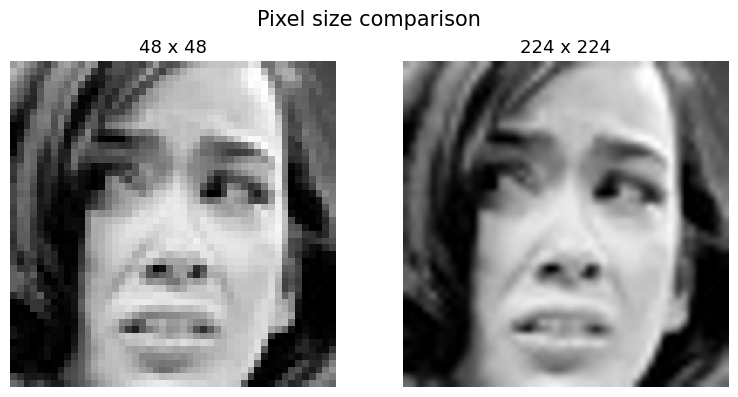

In [6]:
# Display a sample
img_path = r"C:\Users\Sandeep\Desktop\Projects\data\train\disgust\Training_659019.jpg" 

img = Image.open(img_path).convert("RGB")

img_48  = img.resize((48, 48))
img_224 = img.resize((224, 224))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(img_48)
axes[0].set_title("48 x 48", fontsize=13)
axes[0].axis("off")

axes[1].imshow(img_224)
axes[1].set_title("224 x 224", fontsize=13)
axes[1].axis("off")

plt.suptitle("Pixel size comparison", fontsize=15)
plt.tight_layout()
plt.savefig("pixel_comparison.png", dpi=150)  # saves to your project folder
plt.show()

In [ ]:
class EmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()

        # --- Feature Extractor ---
        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # (1,48,48) -> (32,48,48)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (32,48,48) -> (32,24,24)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # (32,24,24) -> (64,24,24)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (64,24,24) -> (64,12,12)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),# (64,12,12) -> (128,12,12)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # (128,12,12) -> (128,6,6)
        )

        # --- Classifier ---
        self.classifier = nn.Sequential(
            nn.Flatten(),                                 # (128,6,6) -> (4608,)
            nn.Linear(128 * 6 * 6, 256),
            nn.ReLU(),
            nn.Dropout(0.5),                             # randomly drops 50% neurons
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes)                   # final output = 7
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# --- sanity check ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = EmotionCNN(num_classes=6).to(device)

# pass a fake batch through to confirm shapes work
dummy = torch.randn(32, 1, 48, 48).to(device)  # fake batch of 32 images
output = model(dummy)
print(output.shape)  # should print torch.Size([32, 7])

torch.Size([32, 6])


In [7]:
# --- setup ---
criterion = nn.CrossEntropyLoss()          # loss function for multi-class classification
optimizer = Adam(model.parameters(), lr=0.001)

num_epochs = 25

# --- training loop ---
for epoch in range(num_epochs):

    # ---- train phase ----
    model.train()                           # sets model to training mode (dropout active)
    train_loss = 0
    train_correct = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()               # clear gradients from last step
        outputs = model(images)             # forward pass
        loss = criterion(outputs, labels)   # calculate loss
        loss.backward()                     # backward pass
        optimizer.step()                    # update weights

        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc  = train_correct / len(train_loader) * 100
    train_loss = train_loss / len(train_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Loss: {train_loss:.4f}  "
          f"Accuracy: {train_acc:.2f}%")

Epoch [1/25]  Loss: 0.8911  Accuracy: 2121.92%
Epoch [2/25]  Loss: 0.8893  Accuracy: 2128.43%
Epoch [3/25]  Loss: 0.8863  Accuracy: 2130.55%
Epoch [4/25]  Loss: 0.8803  Accuracy: 2135.08%


KeyboardInterrupt: 

In [26]:
# 1st Trial
for epoch in range(num_epochs):

    # ---- train phase ----
    model.train()
    train_loss, train_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc  = train_correct / len(train_subset) * 100
    train_loss = train_loss / len(train_loader)

    # ---- validation phase ----
    model.eval()                            # dropout OFF during validation
    val_loss, val_correct = 0, 0

    with torch.no_grad():                   # no gradient calculation needed
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc  = val_correct / len(val_subset) * 100
    val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%")

KeyboardInterrupt: 

In [ ]:
# --- Trial 2 ---
# Adding an early stopping and saving the best model
model = EmotionCNN(num_classes = 7).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

num_epochs    = 50        # train longer, early stopping will decide when to stop
patience      = 7         # stop if val loss doesn't improve for 7 epochs
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(num_epochs):

    # ---- train phase ----
    model.train()
    train_loss, train_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc  = train_correct / len(train_subset) * 100
    train_loss = train_loss / len(train_loader)

    # ---- validation phase ----
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc  = val_correct / len(val_subset) * 100
    val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")  # save best weights
        print(f"  ✓ Best model saved (val loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# load the best weights back after training ends
model.load_state_dict(torch.load("best_model.pth"))
print("Best model loaded")

RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1.
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [6]:
# ---Trial 3 ---
# Removing disgust
model = EmotionCNN(num_classes = 6).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

num_epochs    = 100        # train longer, early stopping will decide when to stop
patience      = 10         # stop if val loss doesn't improve for 7 epochs
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(num_epochs):

    # ---- train phase ----
    model.train()
    train_loss, train_correct = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc  = train_correct / len(train_subset) * 100
    train_loss = train_loss / len(train_loader)

    # ---- validation phase ----
    model.eval()
    val_loss, val_correct = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            val_loss    += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc  = val_correct / len(val_subset) * 100
    val_loss = val_loss / len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}]  "
          f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.2f}%  |  "
          f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.2f}%")

    # ---- early stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")  # save best weights
        print(f"  ✓ Best model saved (val loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{patience})")

        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

# load the best weights back after training ends
model.load_state_dict(torch.load("best_model.pth"))
print("Best model loaded")

Epoch [1/100]  Train Loss: 1.7002  Train Acc: 27.30%  |  Val Loss: 1.5089  Val Acc: 38.83%
  ✓ Best model saved (val loss: 1.5089)
Epoch [2/100]  Train Loss: 1.5373  Train Acc: 36.59%  |  Val Loss: 1.4424  Val Acc: 40.80%
  ✓ Best model saved (val loss: 1.4424)
Epoch [3/100]  Train Loss: 1.4645  Train Acc: 39.36%  |  Val Loss: 1.3931  Val Acc: 45.62%
  ✓ Best model saved (val loss: 1.3931)
Epoch [4/100]  Train Loss: 1.4289  Train Acc: 41.58%  |  Val Loss: 1.3824  Val Acc: 47.27%
  ✓ Best model saved (val loss: 1.3824)
Epoch [5/100]  Train Loss: 1.4075  Train Acc: 42.54%  |  Val Loss: 1.3414  Val Acc: 48.81%
  ✓ Best model saved (val loss: 1.3414)
Epoch [6/100]  Train Loss: 1.3830  Train Acc: 43.74%  |  Val Loss: 1.3279  Val Acc: 49.81%
  ✓ Best model saved (val loss: 1.3279)
Epoch [7/100]  Train Loss: 1.3583  Train Acc: 44.88%  |  Val Loss: 1.2987  Val Acc: 50.22%
  ✓ Best model saved (val loss: 1.2987)
Epoch [8/100]  Train Loss: 1.3410  Train Acc: 45.99%  |  Val Loss: 1.2682  Val Acc: